# COVID-19 Daily Data Analysis

### Professional Data Analysis Project
Tasks included: 
1. Data Cleaning
2. Exploratory Data Analysis (EDA)
3. Outlier and Skewness treatment
4. Visualization
5. Exporting cleaned data for Power BI/SQL

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

sns.set(style='whitegrid')

# 1. Load Data
file_path = r'c:\Users\Admin\Downloads\covid 19\worldometer_coronavirus_daily_data.csv'
df = pd.read_csv(file_path)

# 2. Initial Data Inspection
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nData info:")
print(df.info())

Shape of dataset: (184787, 7)

First 5 rows:


,date,country,cumulative_total_cases,daily_new_cases,active_cases,cumulative_total_deaths,daily_new_deaths
0,2020-2-15,Afghanistan,0.0,NaN,0.0,0.0,NaN
1,2020-2-16,Afghanistan,0.0,NaN,0.0,0.0,NaN
2,2020-2-17,Afghanistan,0.0,NaN,0.0,0.0,NaN
3,2020-2-18,Afghanistan,0.0,NaN,0.0,0.0,NaN
4,2020-2-19,Afghanistan,0.0,NaN,0.0,0.0,NaN



Data info:
<class 'pandas.DataFrame'>
RangeIndex: 184787 entries, 0 to 184786
Data columns (total 7 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   date                     184787 non-null  str    
 1   country                  184787 non-null  str    
 2   cumulative_total_cases   184787 non-null  float64
 3   daily_new_cases          174329 non-null  float64
 4   active_cases             166747 non-null  float64
 5   cumulative_total_deaths  178227 non-null  float64
 6   daily_new_deaths         157850 non-null  float64
dtypes: float64(5), str(2)
memory usage: 9.9 MB
None


In [2]:
# 3. Data Cleaning + basic feature engineering

# Convert date to datetime and derive more columns
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
# week of year could be helpful
df['weekofyear'] = df['date'].dt.isocalendar().week

# Fill missing numeric values with 0
cols_to_fill = ['cumulative_total_cases', 'daily_new_cases', 'active_cases', 
                'cumulative_total_deaths', 'daily_new_deaths']
df[cols_to_fill] = df[cols_to_fill].fillna(0)

# Drop duplicates now that we've added derived date columns
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f"Dropped {before-after} duplicate rows")

# remove any columns that are clearly unneeded (e.g. 'url' or 'source' if present)
for col in ['source', 'url', 'latitude', 'longitude']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)
        print(f"Removed redundant column: {col}")

print("Missing values after cleaning:\n", df.isnull().sum())

# Encode categorical columns using simple mapping / one-hot
# but keep country column as-is for grouping/analysis later
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['date', 'country']]

if cat_cols:
    print("Encoding categorical columns:", cat_cols)
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
else:
    print("No categorical columns to encode.")

# final check on dataframe shape
print("Final dataframe shape:", df.shape)

Dropped 0 duplicate rows
Missing values after cleaning:
 date                       0
country                    0
cumulative_total_cases     0
daily_new_cases            0
active_cases               0
cumulative_total_deaths    0
daily_new_deaths           0
year                       0
month                      0
weekofyear                 0
dtype: int64
No categorical columns to encode.
Final dataframe shape: (184787, 10)


C:\Users\Admin\AppData\Local\Temp\ipykernel_7648\1155656006.py:31: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


--- Summary Statistics ---
                             date  cumulative_total_cases  daily_new_cases  \
count                      184787            1.847870e+05    184787.000000   
mean   2021-03-30 20:11:51.556548            7.251089e+05      2818.548507   
min           2020-01-22 00:00:00            0.000000e+00      -322.000000   
25%           2020-09-07 00:00:00            1.099000e+03         0.000000   
50%           2021-03-31 00:00:00            1.775600e+04        41.000000   
75%           2021-10-22 00:00:00            2.238085e+05       636.000000   
max           2022-05-14 00:00:00            8.420947e+07    909610.000000   
std                           NaN            3.681471e+06     17305.881476   

       active_cases  cumulative_total_deaths  daily_new_deaths           year  \
count  1.847870e+05             1.847870e+05     184787.000000  184787.000000   
mean   5.630167e+04             1.339304e+04         34.025418    2020.772901   
min   -1.432100e+04        

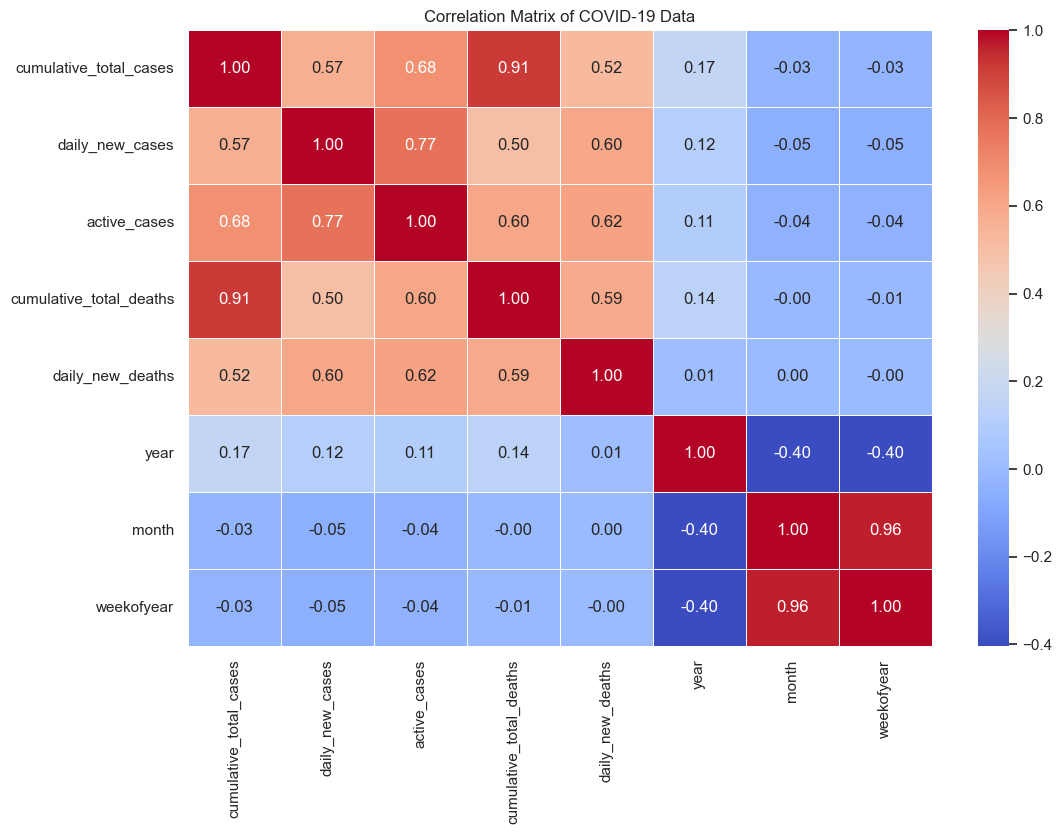


Summary statistics and correlation matrix saved to CSV.


In [3]:
# 4. Summary & Correlation (using current dataframe)

# 1. Summary Statistics
print("--- Summary Statistics ---")
summary_stats = df.describe()
print(summary_stats)

# 2. Correlation Analysis
numeric_df = df.select_dtypes(include=[np.number])  # grab just numbers
correlation_matrix = numeric_df.corr()
print("\n--- Correlation Matrix ---")
print(correlation_matrix)

# 3. Plot Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of COVID-19 Data')
plt.show()

# 4. Save Summary Statistics to CSV
summary_stats.to_csv('summary_statistics.csv')
correlation_matrix.to_csv('correlation_matrix.csv')
print("\nSummary statistics and correlation matrix saved to CSV.")

In [4]:
# 4. EDA - Statistical Summary
display(df.describe())

,date,cumulative_total_cases,daily_new_cases,active_cases,cumulative_total_deaths,daily_new_deaths,year,month,weekofyear
count,184787,1.847870e+05,184787.000000,1.847870e+05,1.847870e+05,184787.000000,184787.000000,184787.000000,184787.0
mean,2021-03-30 20:11:51.556548,7.251089e+05,2818.548507,5.630167e+04,1.339304e+04,34.025418,2020.772901,6.191296,25.355106
min,2020-01-22 00:00:00,0.000000e+00,-322.000000,-1.432100e+04,0.000000e+00,-39.000000,2020.000000,1.000000,1.0
25%,2020-09-07 00:00:00,1.099000e+03,0.000000,9.000000e+00,1.200000e+01,0.000000,2020.000000,3.000000,12.0
50%,2021-03-31 00:00:00,1.775600e+04,41.000000,8.110000e+02,2.580000e+02,0.000000,2021.000000,6.000000,24.0
75%,2021-10-22 00:00:00,2.238085e+05,636.000000,1.147900e+04,3.696000e+03,8.000000,2021.000000,9.000000,38.0
max,2022-05-14 00:00:00,8.420947e+07,909610.000000,1.793543e+07,1.026646e+06,5093.000000,2022.000000,12.000000,53.0
std,NaN,3.681471e+06,17305.881476,3.762157e+05,5.946724e+04,167.972177,0.709436,3.405413,14.973197


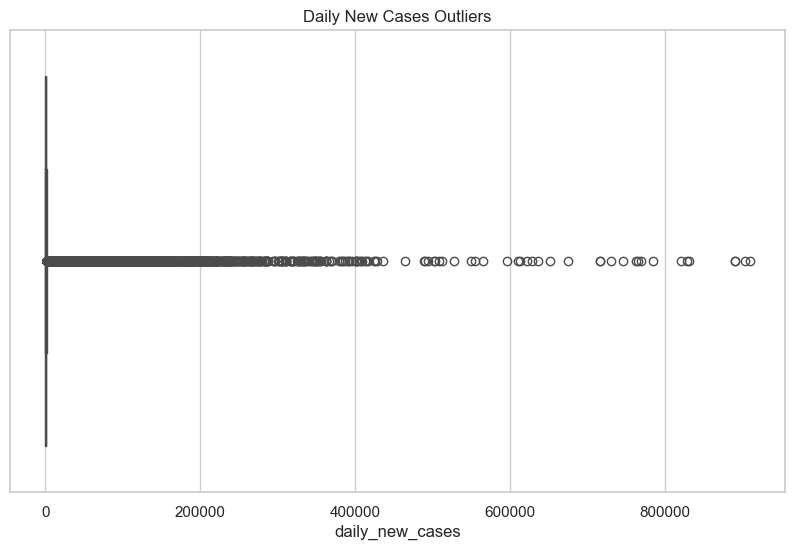

Capping outliers above 1590.00 and below -954.00


In [5]:
# 5. Outlier Detection and Treatment

# Visualize outliers with Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['daily_new_cases'])
plt.title('Daily New Cases Outliers')
plt.show()

# Calculate IQR
Q1 = df['daily_new_cases'].quantile(0.25)
Q3 = df['daily_new_cases'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap outliers to avoid data loss
df['daily_new_cases_cleaned'] = np.where(df['daily_new_cases'] > upper_bound, upper_bound, 
                                        np.where(df['daily_new_cases'] < lower_bound, lower_bound, df['daily_new_cases']))

print(f"Capping outliers above {upper_bound:.2f} and below {lower_bound:.2f}")

# note: keep original column so we can compare later or use in skewness step


Skewness of data (daily_new_cases_cleaned): 1.2137561605624148


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


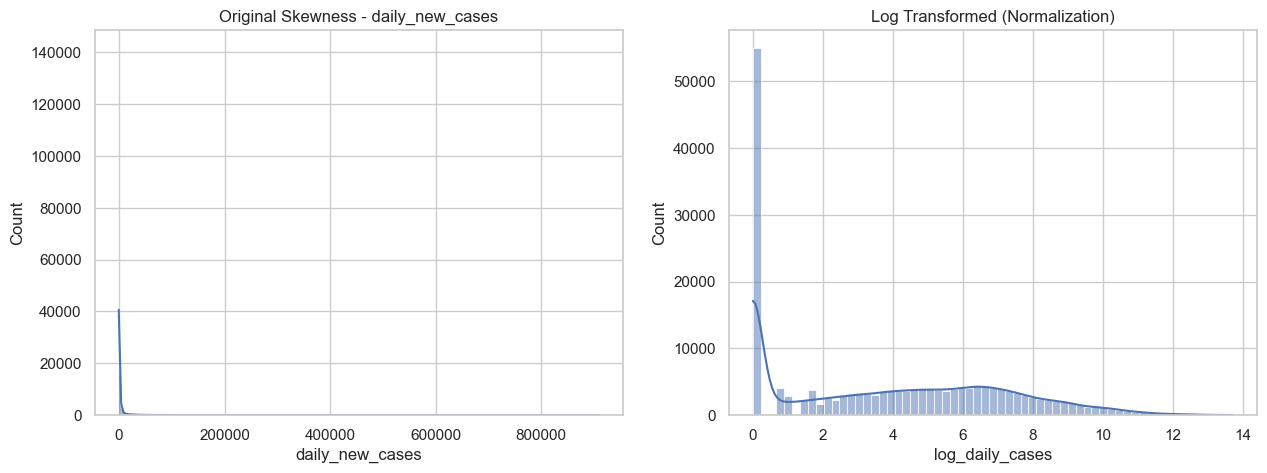

Skewness after transformation: nan


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\nanops.py:1263: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


In [6]:
# 6. Skewness Analysis and Treatment

# pick whichever column exists for new cases
cases_col = 'daily_new_cases'
if 'daily_new_cases_cleaned' in df.columns:
    cases_col = 'daily_new_cases_cleaned'

print(f"Skewness of data ({cases_col}):", df[cases_col].skew())

# if original column exists and is different, create log transform from it; otherwise use cleaned
base_col = 'daily_new_cases' if 'daily_new_cases' in df.columns else cases_col

df['log_daily_cases'] = np.log1p(df[base_col])

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(df[base_col], kde=True)
plt.title('Original Skewness - ' + base_col)

plt.subplot(1, 2, 2)
sns.histplot(df['log_daily_cases'], kde=True)
plt.title('Log Transformed (Normalization)')
plt.show()

print("Skewness after transformation:", df['log_daily_cases'].skew())

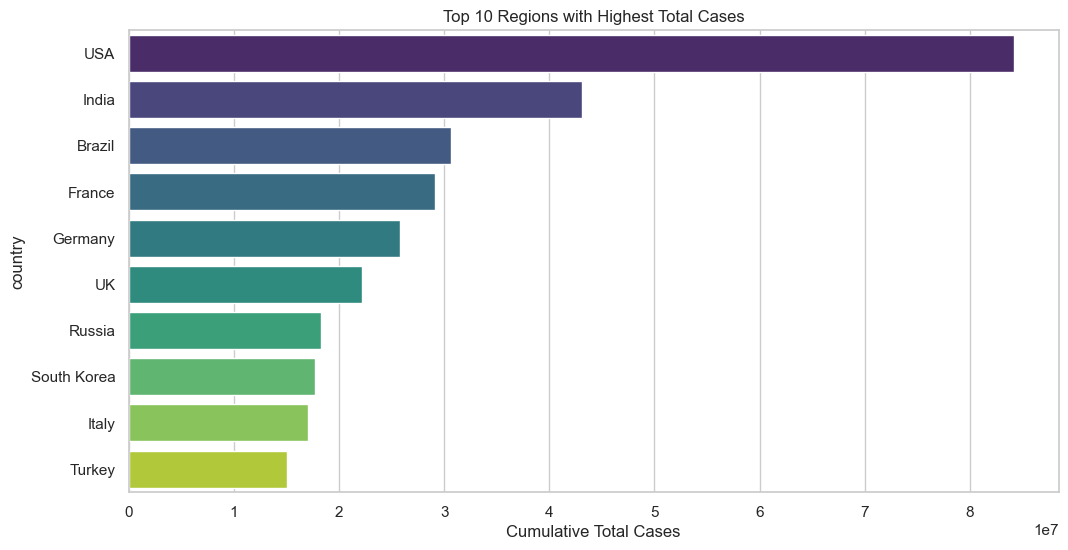

In [7]:
# 7. Analysis: Regions with Highest Infection Rates

top_infected = df.groupby('country')['cumulative_total_cases'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_infected.values, y=top_infected.index, hue=top_infected.index, palette='viridis', legend=False)
plt.title('Top 10 Regions with Highest Total Cases')
plt.xlabel('Cumulative Total Cases')
plt.show()

In [8]:
# 8. Save Cleaned Dataset
output_file = 'cleaned_covid_data.csv'
df.to_csv(output_file, index=False)
print(f"Dataset saved to {output_file}")

Dataset saved to cleaned_covid_data.csv
